In [21]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, Sequential
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import cv2
import torch
import os

In [2]:
print(np.__version__)

2.4.3


In [85]:
fish = pd.read_csv("fish_dataset/fish_dataset_metadata/all_downloaded_images-checkpoint.csv")

In [27]:
folder_path = "fish_dataset/inat_fish_dataset"
print(f'folder exists {os.path.exists(folder_path)}')
img_list = []
for folder in os.listdir(folder_path):
    for name in os.listdir(folder_path+"/"+folder):
        if name.lower().endswith(".jpg"):
            # fullpath = os.path.join(folder_path,name)
            fullpath = folder_path + "/" + folder + "/" + name
            try:
                img = Image.open(fullpath)
                img.load()
                img_list.append({"Image": img})
            except Exception as e:
                print(f"Error opening  {name}: {e}")
print(img_list)


folder exists True
[{'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x711 at 0x13FE49EEE40>}, {'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x768 at 0x13FE48E78C0>}, {'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x768 at 0x13FE49EEE10>}, {'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x1024 at 0x13FE49FDCD0>}, {'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x1024 at 0x13FE49FE600>}, {'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=904x508 at 0x13FE49FFAA0>}, {'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x461 at 0x13FE4A01FD0>}, {'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=474x1024 at 0x13FE2F91490>}, {'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=694x471 at 0x13FE49ED0A0>}, {'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x768 at 0x13FE49EF470>}, {'Image': <PIL.JpegImagePlugin.JpegImageFi

In [31]:
print(len(img_list))

6000


In [88]:
test_path = "fish_dataset/" + fish['img_path'].iloc[0]
img = Image.open(test_path)
img_array = np.array(img)
tensor = tf.convert_to_tensor(img_array)
print(test_path)
print(os.path.exists(test_path))
print(img_array.flatten())
# # print(tensor)
# print(tf.nest.flatten(tensor))

fish_dataset/inat_fish_dataset/Lepomis_macrochirus/00001_445000b65d.jpg
True
[119 116  97 ...   7  67 130]


In [90]:
for i in range(len(fish['img_path'])):
    image_path = "fish_dataset/" + fish['img_path'].iloc[i]
    if image_path.lower().endswith(".jpg"):
            # fullpath = os.path.join(folder_path,name)
            try:
                img = Image.open(image_path)
                # img.load()
                img_array = np.array(img)
                # tensor = tf.convert_to_tensor(img_array)
                fish['Image'] = [img_array.flatten()] * len(fish)
                # fish['Image'] = tensor
            except Exception as e:
                print(f"Error opening  {name}: {e}")

Error opening  00030_aeb84e9583.jpg: [Errno 2] No such file or directory: 'fish_dataset/inat_fish_dataset/Cyprinus_carpio/00013_7eeeaf6ef8.jpg'
Error opening  00030_aeb84e9583.jpg: [Errno 2] No such file or directory: 'fish_dataset/inat_fish_dataset/Micropterus_dolomieu/00002_dd63f64121.jpg'


In [123]:
fish['Image'] = np.stack(fish['Image']).astype(np.int32)

ValueError: all input arrays must have the same shape

In [91]:
fishes = list(fish['common_name'].unique())
print(fishes)
len(fishes)
fish_labels = {}
label_num = 0
for label in fishes:
    fish_labels[label] = label_num
    label_num += 1
print(fish_labels)

['Bluegill', 'Largemouth Bass', 'European Carp', 'Rainbow Trout', 'Green Sunfish', 'Bluefin Leatherjacket', 'Western Mosquitofish', 'Pumpkinseed', 'Smallmouth Bass', 'Brown Trout', 'Eastern Mosquitofish', 'Northern Pike', 'Creek Chub', 'Brook Trout', 'Moorish Idol', 'Channel Catfish', 'Yellow Perch', 'Redbreast Sunfish', 'Atlantic Sergeant Major', 'European Perch', 'Salema Porgy', 'Rock Bass', 'Ornate Wrasse', 'Black Crappie', 'Common Two-banded Seabream', 'Threespine Stickleback', 'Atlantic Blue Tang', 'Tidepool Sculpin', 'Great Barracuda', 'Blue-spotted Cornetfish', 'White sea bream', 'Pinfish', 'Spotted Porcupinefish', 'Indo-Pacific Sergeant Major', 'Threadfin Butterflyfish', 'Mediterranean Rainbow Wrasse', 'Woolly Sculpin', 'Goldfish', 'Common Lionfish', 'Globefish', 'Chinook Salmon', 'Caribbean Bluehead Wrasse', 'Painted Comber', 'White Sucker', 'Mediterranean Damselfish', 'Stoplight Parrotfish', 'Gray Snapper', 'Rainbow Darter', 'European chub', 'Amur Carp', 'Longspined Porcupine

In [92]:
fish["Label"] = fish["common_name"].map(fish_labels)

In [96]:
fish.head()

,scientific_name,common_name,obs_id,photo_id,license_code,img_path,source_url,Image,Label
0,Lepomis macrochirus,Bluegill,330732255,599807589,CC-BY-NC,inat_fish_dataset/Lepomis_macrochirus/00001_44...,https://inaturalist-open-data.s3.amazonaws.com...,"[57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...",0
1,Lepomis macrochirus,Bluegill,333405187,605289342,CC-BY-NC,inat_fish_dataset/Lepomis_macrochirus/00002_17...,https://inaturalist-open-data.s3.amazonaws.com...,"[57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...",0
2,Lepomis macrochirus,Bluegill,330108367,598522950,CC-BY-NC,inat_fish_dataset/Lepomis_macrochirus/00003_6d...,https://inaturalist-open-data.s3.amazonaws.com...,"[57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...",0
3,Lepomis macrochirus,Bluegill,334139857,606729497,CC-BY,inat_fish_dataset/Lepomis_macrochirus/00004_76...,https://inaturalist-open-data.s3.amazonaws.com...,"[57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...",0
6,Lepomis macrochirus,Bluegill,333682704,605799928,CC-BY-NC,inat_fish_dataset/Lepomis_macrochirus/00007_ed...,https://inaturalist-open-data.s3.amazonaws.com...,"[57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...",0


In [114]:
fish.shape

(4854, 9)

In [94]:
fish.dropna(inplace=True)

In [95]:
fish.shape

(4853, 9)

image resize

In [13]:

input_folder = "fish_dataset/inat_fish_dataset"
output_folder = "fish_dataset/all_fish"
size = (400,400)
for i in os.listdir(input_folder):
    if i.lower().endswith(('.jpg')):
        img_path = os.path.join(input_folder, i)
        img = cv2.imread(img_path)
        resized_img = cv2.resize(img,new_size, interpolation= cv2.INTER_AREA)
        cv2.imwrite(os.path.join(output_folder,i),resized_img)
        print(i)

In [97]:
x = fish["Image"]
y = fish["Label"]
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 98)

print(x_test)
print(x_train)
print(y_test)
print(y_train)
# x_train = np.array(x_train.tolist(), dtype = np.float32())
# x_test.index
# x_test = np.array(x_test.tolist(), dtype= np.float32())


4659    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
4599    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
1726    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
761     [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
528     [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
                              ...                        
4405    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
1012    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
1962    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
3051    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
698     [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
Name: Image, Length: 971, dtype: object
4878    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
227     [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
2812    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
4520    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
3502    [57, 106, 146, 60, 109, 149, 60, 109, 149, 60,...
                              ..

In [3]:
batch_size = 32
img_height = 180
img_width = 180

In [6]:
data_dir = "fish_dataset/inat_fish_dataset"
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6012 files belonging to 200 classes.
Using 4810 files for training.


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6012 files belonging to 200 classes.
Using 1202 files for validation.


In [8]:
class_names = train_ds.class_names
print(class_names)

['Abudefduf_saxatilis', 'Abudefduf_sexfasciatus', 'Abudefduf_sordidus', 'Abudefduf_troschelii', 'Abudefduf_vaigiensis', 'Acanthopagrus_australis', 'Acanthurus_coeruleus', 'Acanthurus_lineatus', 'Acanthurus_nigrofuscus', 'Acanthurus_sandvicensis', 'Acanthurus_tractus', 'Acanthurus_triostegus', 'Achoerodus_viridis', 'Aluterus_scriptus', 'Ambloplites_rupestris', 'Ameiurus_melas', 'Ameiurus_natalis', 'Ameiurus_nebulosus', 'Amphiprion_clarkii', 'Amphiprion_ocellaris', 'Anguilla_rostrata', 'Aplodinotus_grunniens', 'Aracana_ornata', 'Archosargus_probatocephalus', 'Ariopsis_felis', 'Arothron_hispidus', 'Arothron_meleagris', 'Arothron_nigropunctatus', 'Aulostomus_chinensis', 'Aulostomus_maculatus', 'Balistapus_undulatus', 'Balistoides_viridescens', 'Brevoortia_tyrannus', 'Campostoma_anomalum', 'Canthigaster_valentini', 'Caranx_melampygus', 'Caranx_ruber', 'Carassius_auratus', 'Carassius_gibelio', 'Catostomus_commersonii', 'Cephalopholis_argus', 'Chaetodon_auriga', 'Chaetodon_capistratus', 'Chae

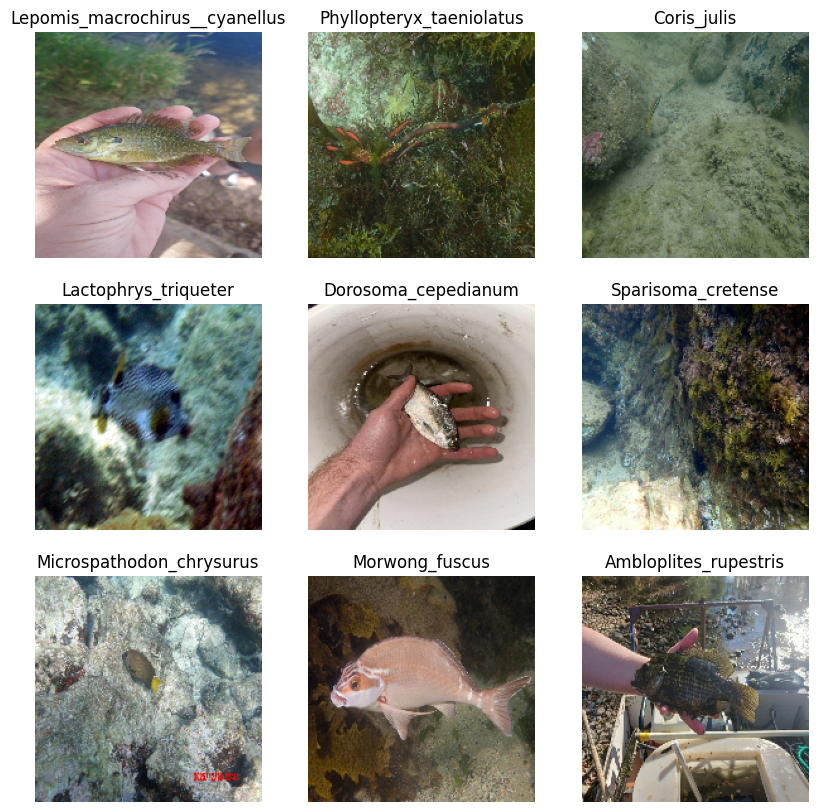

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [10]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [12]:
normalization_layer = layers.Rescaling(1./255)

In [13]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.001019852 1.0


In [14]:
num_classes = len(class_names)
print(num_classes)

200


In [30]:
num_classes = len(class_names)

model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

c:\Users\yorba\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [32]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 41s 258ms/step - accuracy: 0.0050 - loss: 5.3002 - val_accuracy: 0.0075 - val_loss: 5.2755
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 55s 366ms/step - accuracy: 0.0075 - loss: 5.1797 - val_accuracy: 0.0125 - val_loss: 5.1074
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 106s 700ms/step - accuracy: 0.0114 - loss: 5.0630 - val_accuracy: 0.0100 - val_loss: 5.0826
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 37s 241ms/step - accuracy: 0.0125 - loss: 5.0027 - val_accuracy: 0.0150 - val_loss: 5.0272
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 34s 226ms/step - accuracy: 0.0310 - loss: 4.8602 - val_accuracy: 0.0141 - val_loss: 5.0297
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 31s 207ms/step - accuracy: 0.0844 - loss: 4.4588 - val_accuracy: 0.0175 - val_loss: 5.1959
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 31s 207ms/step - accuracy: 0.2268 - loss: 3.6204 - val_accuracy: 0.0208 - val_loss: 5.8545
Epoch 8/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 41s 272ms/step - accuracy: 0.4247 - loss: 

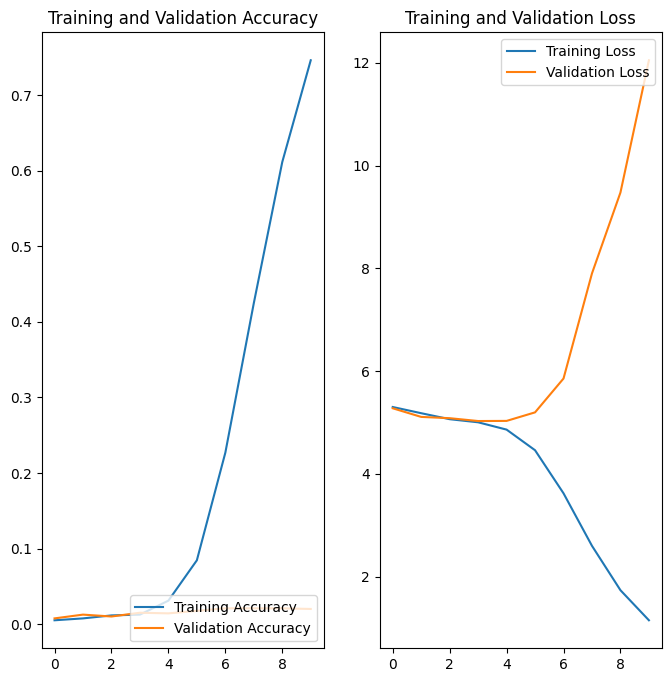

In [33]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [39]:
data_augmentation = Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

c:\Users\yorba\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


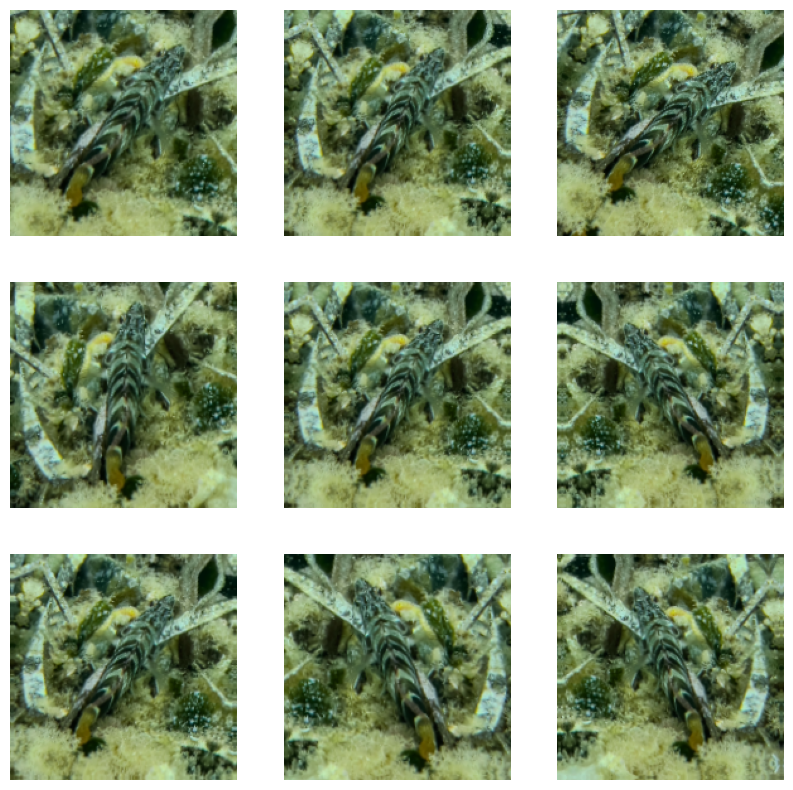

In [23]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [40]:
dmodel = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])

In [41]:
dmodel.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,014,440 (15.31 MB)

 Trainable params: 4,014,440 (15.31 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
dmodel.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [44]:
epochs = 30
history = dmodel.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 58s 363ms/step - accuracy: 0.0079 - loss: 5.2749 - val_accuracy: 0.0133 - val_loss: 5.1754
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 67s 440ms/step - accuracy: 0.0079 - loss: 5.1271 - val_accuracy: 0.0075 - val_loss: 5.1023
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 42s 279ms/step - accuracy: 0.0100 - loss: 5.0499 - val_accuracy: 0.0116 - val_loss: 5.0719
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 38s 254ms/step - accuracy: 0.0139 - loss: 5.0071 - val_accuracy: 0.0216 - val_loss: 5.0110
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 38s 249ms/step - accuracy: 0.0210 - loss: 4.9499 - val_accuracy: 0.0233 - val_loss: 5.0142
Epoch 6/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 41s 270ms/step - accuracy: 0.0237 - loss: 4.8996 - val_accuracy: 0.0241 - val_loss: 5.0349
Epoch 7/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 34s 223ms/step - accuracy: 0.0301 - loss: 4.8362 - val_accuracy: 0.0208 - val_loss: 5.0216
Epoch 8/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 34s 224ms/step - accuracy: 0.0324 - loss: 4

In [48]:
dmodel.save('model_59.keras')

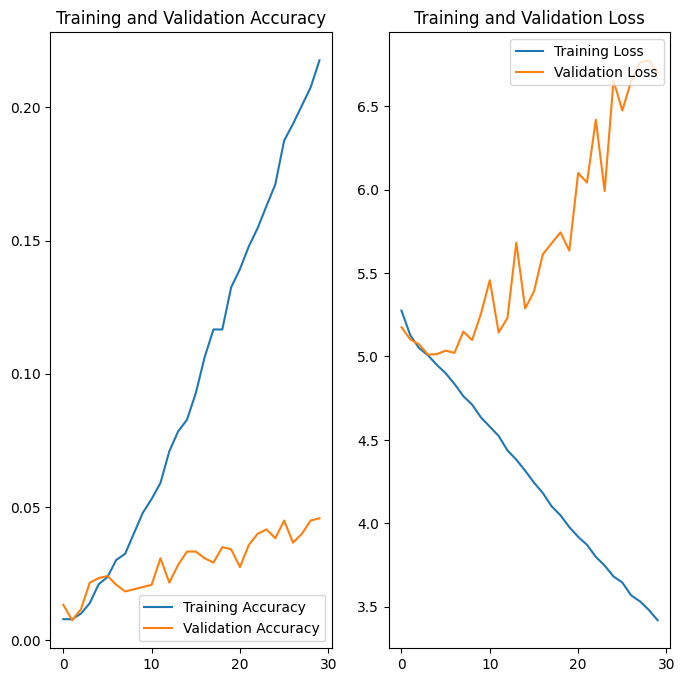

In [45]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [56]:
eel_url = "https://www.monaconatureencyclopedia.com/wp-content/uploads/2021/08/1-Aluterus-scriptus-%C2%A9-Paddy-Ryan.jpg"
eel_path = tf.keras.utils.get_file('Aluterus_scriptus', origin=eel_url)

img = tf.keras.utils.load_img(
    eel_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = dmodel.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

139743/139743 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
This image most likely belongs to Acanthurus_lineatus with a 99.06 percent confidence.


In [25]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [100]:
model = models.Sequential()
model.add(layers.Input(shape=(32,32,3)))
model.add(layers.Conv2D(32, (3, 3), activation = 'relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3), activation= 'relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3), activation = 'relu'))


In [101]:
model.add(layers.Flatten())
model.add(layers.Dense(64,activation = 'relu'))
model.add(layers.Dense(10))

In [139]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,014,440 (15.31 MB)

 Trainable params: 4,014,440 (15.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits= True),metrics=['accuracy'])
history = model.fit( epochs= 10, validation_data= (x_test, y_test))

ValueError: Invalid dtype: object

In [104]:
print(fish.dtypes)

scientific_name       str
common_name           str
obs_id              int64
photo_id            int64
license_code          str
img_path              str
source_url            str
Image              object
Label               int64
dtype: object
